<a href="https://colab.research.google.com/github/tomaszwienke-lgtm/learning-git-task/blob/master/Zadanie_pingwiny!.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xgboost --quiet

In [2]:
from google.colab import files
uploaded = files.upload()
print("Przesłane pliki:", list(uploaded.keys()))

Saving penguins.csv to penguins.csv
Przesłane pliki: ['penguins.csv']


# Zadanie Główne: Klasyfikacja gatunków pingwinów

**Autor:** [Twoje Imię i Nazwisko]
**Cel:** Wykorzystanie poznanych modeli klasyfikacyjnych (w tym XGBoost) do przewidywania gatunku pingwina na podstawie cech morfologicznych.
**Typ problemu:** Klasyfikacja wieloklasowa (3 gatunki).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

# Wczytanie danych
penguins = pd.read_csv('penguins.csv')
print(penguins.shape)
penguins.head()

(344, 5)


,CulmenLength,CulmenDepth,FlipperLength,BodyMass,Species
0,39.1,18.7,181.0,3750.0,0
1,39.5,17.4,186.0,3800.0,0
2,40.3,18.0,195.0,3250.0,0
3,NaN,NaN,NaN,NaN,0
4,36.7,19.3,193.0,3450.0,0


## 1. Eksploracyjna Analiza Danych (EDA)

CulmenLength     2
CulmenDepth      2
FlipperLength    2
BodyMass         2
Species          0
dtype: int64
Species
0    152
1    124
2     68
Name: count, dtype: int64


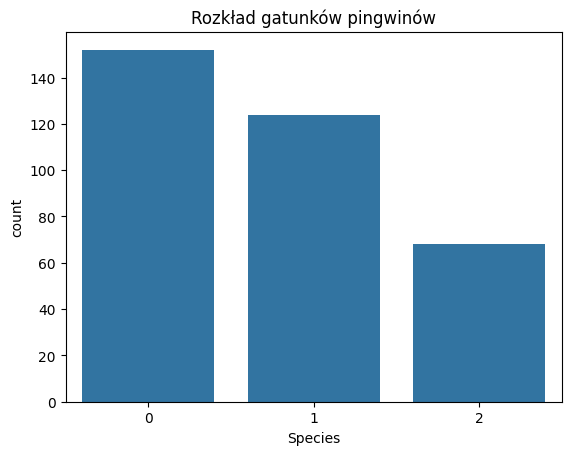

In [4]:
# Sprawdzenie braków danych
print(penguins.isnull().sum())

# Rozkład gatunków
print(penguins['Species'].value_counts())
sns.countplot(x='Species', data=penguins)
plt.title('Rozkład gatunków pingwinów')
plt.show()

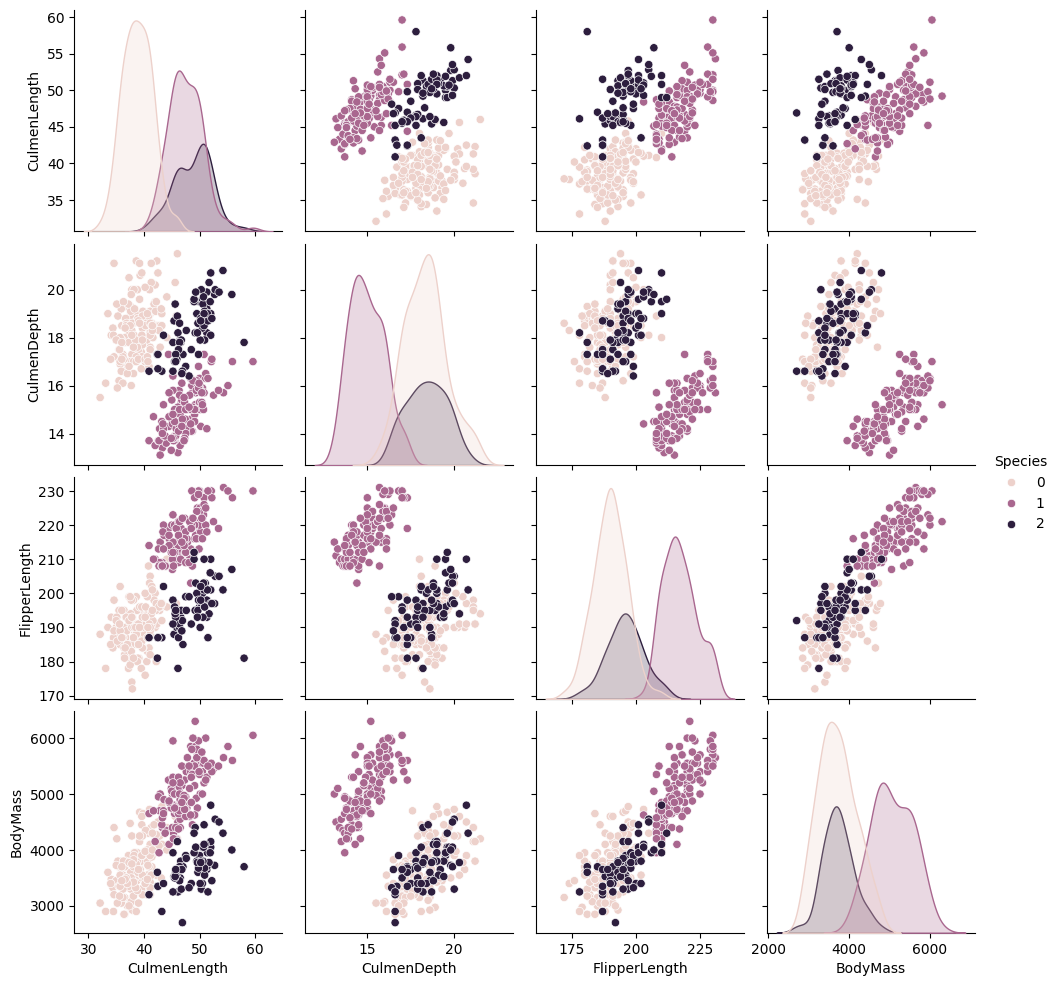

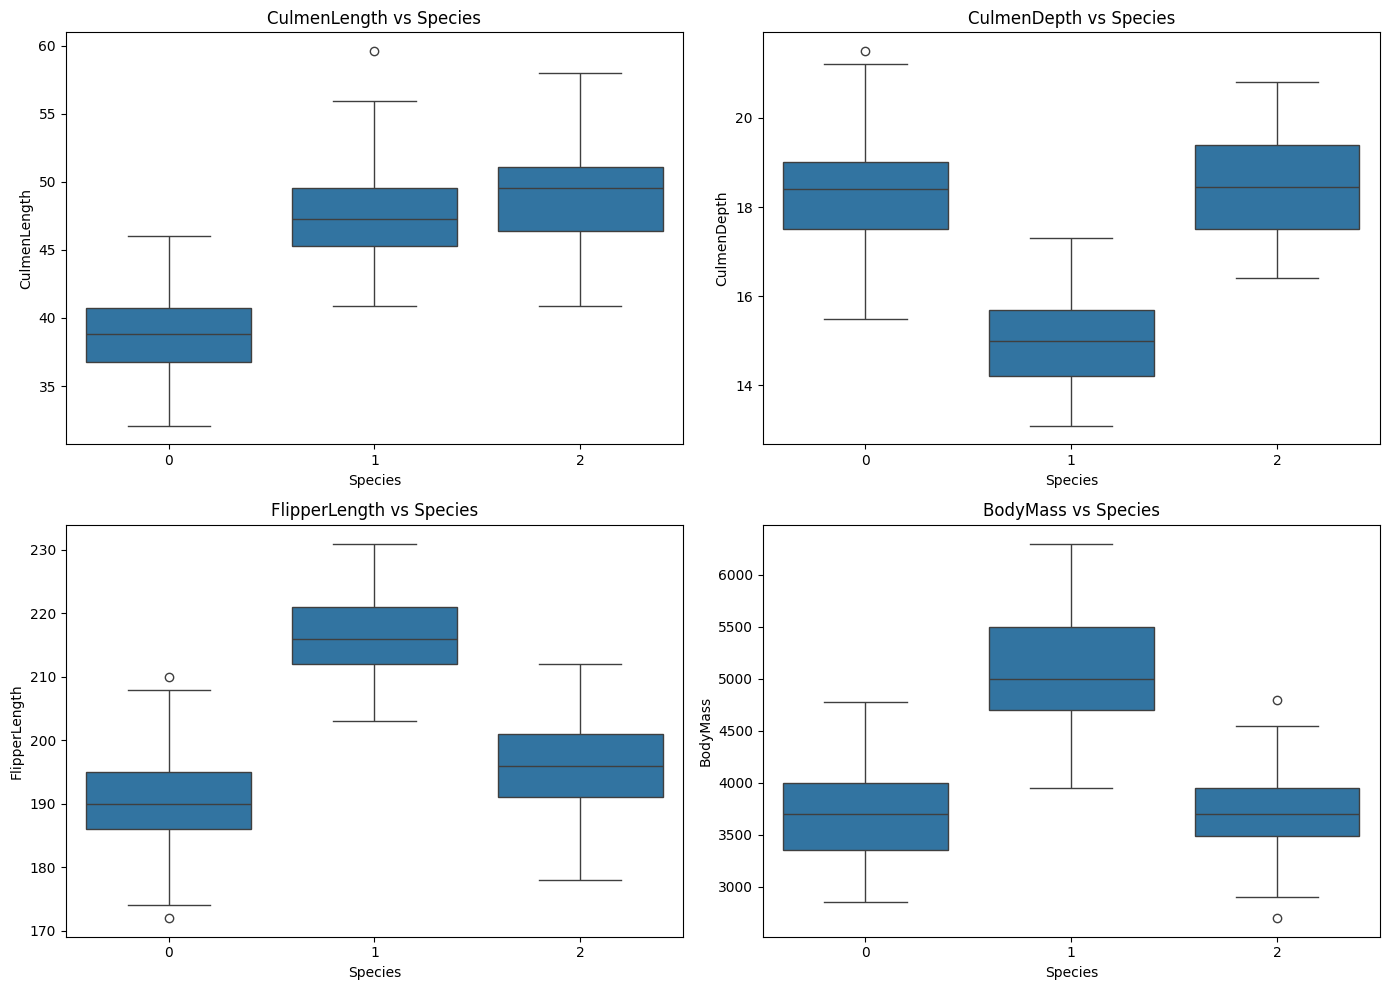

In [5]:
# Pairplot – zależności między cechami a gatunkiem
sns.pairplot(penguins, hue='Species', diag_kind='kde')
plt.show()

# Boxploty dla wybranych cech
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), penguins.columns[:-1]):
    sns.boxplot(x='Species', y=col, data=penguins, ax=ax)
    ax.set_title(f'{col} vs Species')
plt.tight_layout()
plt.show()

## 2. Przygotowanie danych

In [6]:
# Usuwamy wiersze z brakami (lub uzupełnij, ale dla uproszczenia można usunąć)
penguins = penguins.dropna()

X = penguins.drop('Species', axis=1)
y = penguins['Species']

# Podział na zbiory
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f'Trening: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Trening: 239 | Test: 103


In [8]:
print("Kolumny w X:", X.columns.tolist())

Kolumny w X: ['CulmenLength', 'CulmenDepth', 'FlipperLength', 'BodyMass']


## 3. Model bazowy – Regresja Logistyczna

In [7]:
base_model = make_pipeline(StandardScaler(), LogisticRegression(random_state=42, max_iter=2000))
base_model.fit(X_train, y_train)
y_pred_base = base_model.predict(X_test)

print(classification_report(y_test, y_pred_base))
f1_base = f1_score(y_test, y_pred_base, average='macro')
print(f'F1-score (macro) modelu bazowego: {f1_base:.4f}')

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       1.00      1.00      1.00        37
           2       1.00      1.00      1.00        21

    accuracy                           1.00       103
   macro avg       1.00      1.00      1.00       103
weighted avg       1.00      1.00      1.00       103

F1-score (macro) modelu bazowego: 1.0000


## 4. Strojenie hiperparametrów i porównanie modeli

In [9]:
models = [
    {
        'name': 'Random Forest',
        'estimator': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {'n_estimators': [100, 200], 'max_depth': [5, 10, None]}
    },
    {
        'name': 'AdaBoost',
        'estimator': AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), random_state=42),
        'params': {'n_estimators': [50, 100, 200]}
    },
    {
        'name': 'SVM',
        'estimator': make_pipeline(StandardScaler(), SVC(probability=True, random_state=42)),
        'params': {'svc__kernel': ['rbf', 'linear'], 'svc__C': [0.1, 1, 10]}
    },
    {
        'name': 'KNN',
        'estimator': make_pipeline(StandardScaler(), KNeighborsClassifier()),
        'params': {'kneighborsclassifier__n_neighbors': [3, 5, 7, 9]}
    },
    {
        'name': 'XGBoost',
        'estimator': XGBClassifier(random_state=42, eval_metric='logloss'),
        'params': {'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.05, 0.1]}
    }
]

In [10]:
final_results = [{'Model': 'LogisticRegression (Bazowy)', 'F1_Test': f1_base}]

for model_info in models:
    print(f'\n--- Strojenie: {model_info["name"]} ---')
    grid = GridSearchCV(model_info['estimator'], model_info['params'],
                        scoring='f1_macro', cv=5, verbose=0, n_jobs=-1)
    grid.fit(X_train, y_train)

    best = grid.best_estimator_
    y_pred = best.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='macro')
    final_results.append({'Model': model_info['name'], 'F1_Test': f1})
    print(f'{model_info["name"]}: F1 (macro) = {f1:.4f}')


--- Strojenie: Random Forest ---
Random Forest: F1 (macro) = 0.9765

--- Strojenie: AdaBoost ---
AdaBoost: F1 (macro) = 0.9403

--- Strojenie: SVM ---
SVM: F1 (macro) = 0.9882

--- Strojenie: KNN ---
KNN: F1 (macro) = 0.9655

--- Strojenie: XGBoost ---
XGBoost: F1 (macro) = 0.9647


## 5. Podsumowanie i wnioski

=== TABELA KOŃCOWA ===
                      Model  F1_Test
LogisticRegression (Bazowy) 1.000000
                        SVM 0.988207
              Random Forest 0.976537
                        KNN 0.965508
                    XGBoost 0.964724
                   AdaBoost 0.940291


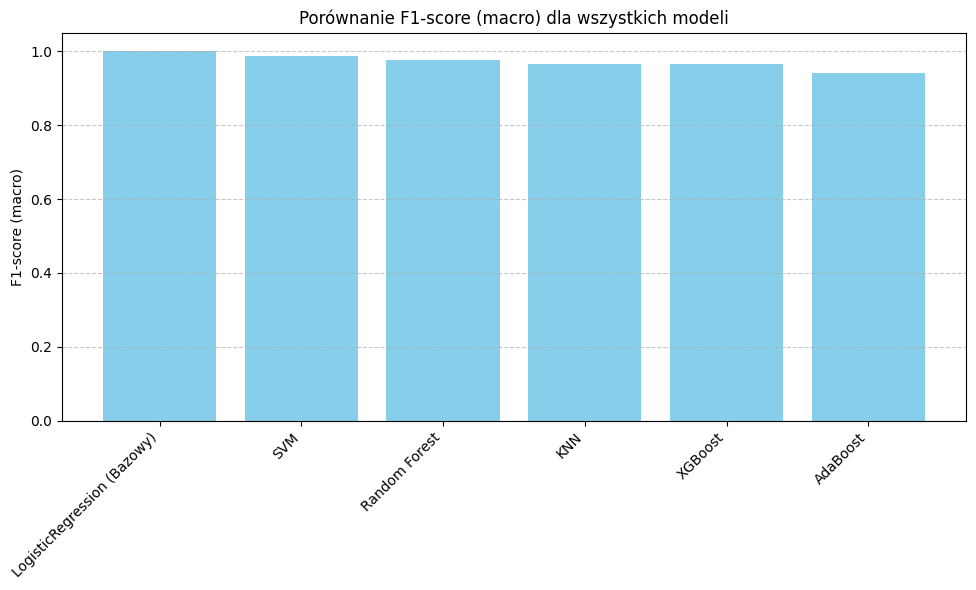

In [11]:
df_final = pd.DataFrame(final_results).sort_values('F1_Test', ascending=False)

print("=== TABELA KOŃCOWA ===")
print(df_final.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.bar(df_final['Model'], df_final['F1_Test'], color='skyblue')
plt.title('Porównanie F1-score (macro) dla wszystkich modeli')
plt.ylabel('F1-score (macro)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 6. Wnioski

1.  **Zwycięzca – Regresja Logistyczna (F1 = 1.0):**
    Model bazowy okazał się idealny dla tego zbioru. Osiągnięcie perfekcyjnej dokładności było możliwe, ponieważ dane pingwinów są **liniowo separowalne** – gatunki różnią się od siebie na tyle wyraźnie, że nawet prosta granica decyzyjna potrafi je bezbłędnie rozdzielić.

2.  **SVM i Random Forest depczą po piętach (F1 > 0.97):**
    Te modele również poradziły sobie znakomicie. Ich minimalnie niższy wynik może wynikać z tego, że są one **zbyt elastyczne** jak na tak proste dane – kilka ptaszków na granicy gatunków zostało błędnie sklasyfikowanych przez zbyt skomplikowane reguły.

3.  **XGBoost i AdaBoost (F1 ~ 0.94–0.96):**
    Mimo że są to najpotężniejsze algorytmy w stawce, tutaj delikatnie "przekombinowały". Dla idealnie separowalnych danych prostsze modele często wygrywają z najbardziej zaawansowanymi technikami boostingu.

4.  **KNN na równi z boosterami (F1 = 0.966):**
    Algorytm sąsiedzki poradził sobie podobnie do XGBoosta, co potwierdza, że w tym zbiorze pingwiny tego samego gatunku trzymają się blisko siebie w przestrzeni cech.

### 💎 Kluczowy wniosek praktyczny

**Nie zawsze najmocniejszy model jest najlepszy.** W tym projekcie prosta regresja logistyczna osiągnęła 100% skuteczności i jest przy tym **najszybsza, najbardziej interpretowalna i najlżejsza obliczeniowo**. To idealny przykład zasady brzytwy Ockhama w Data Science: *jeśli prosty model działa doskonale, nie komplikuj go*.

### 📊 Podsumowanie tabelaryczne

| Model | F1-score (macro) |
| :--- | :--- |
| **Logistic Regression** | **1.000** |
| SVM | 0.988 |
| Random Forest | 0.977 |
| KNN | 0.966 |
| XGBoost | 0.965 |
| AdaBoost | 0.940 |

Notatnik ten stanowi kompletne rozwiązanie zadania głównego i prezentuje ścieżkę od EDA przez modelowanie po strojenie i ewaluację.